<a href="https://colab.research.google.com/github/Shakada26/carisurg-portfolio/blob/main/Week_5_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 5 - AI-Assisted Triage: Data Exploration (Final Submission)
**CariSurg MedTech Pathways — Mercer General Hospital ED AI Pilot**

**Dataset:** `yaleemmlc_admissionprediction_triage.csv` (55,121 patients, 226 features)
**Author:** Shakada Blake
**Question:** is this dataset good enough to build a triage model from, and if so, with what caveats?

This notebook is the full exploration pipeline for the Week 5 feasibility assessment: loading, missingness (two passes), a dtype audit with corrections applied, outlier detection (IQR, z-score, and clinical-plausibility checks), distribution analysis, and correlation analysis against `esi` (the Triage_Level proxy).

## 1. Load the dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)
sns.set_style('whitegrid')
PALETTE = 'crest'

from google.colab import drive
drive.mount('/content/drive')

# Update DATA_PATH to the correct location of your file after mounting Google Drive.
# For example: DATA_PATH = '/content/drive/My Drive/path/to/your/yaleemmlc_admissionprediction_triage.csv'
DATA_PATH = '/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv'

df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded dataset: {df.shape[0]:,} rows x {df.shape[1]} columns")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded dataset: 55,121 rows x 226 columns


In [ ]:
df.shape

(55121, 226)

## 2. Structure: `.info()`, `.describe()`, dtype audit

In [ ]:
df.info(verbose=True, show_counts=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55121 entries, 0 to 55120
Data columns (total 226 columns):
 #    Column                                   Non-Null Count  Dtype  
---   ------                                   --------------  -----  
 0    Unnamed: 0                               55121 non-null  int64  
 1    dep_name                                 55121 non-null  object 
 2    esi                                      55121 non-null  float64
 3    age                                      55121 non-null  float64
 4    gender                                   55121 non-null  object 
 5    ethnicity                                55121 non-null  object 
 6    race                                     55121 non-null  object 
 7    lang                                     55121 non-null  object 
 8    religion                                 55121 non-null  object 
 9    maritalstatus                            55121 non-null  object 
 10   employstatus                    

In [ ]:
non_cc_cols = [c for c in df.columns if not c.startswith('cc_')]
vital_cols = ['age', 'triage_vital_hr', 'triage_vital_sbp', 'triage_vital_dbp',
              'triage_vital_rr', 'triage_vital_o2', 'triage_vital_temp', 'triage_glucose']
vital_labels = {
    'age': 'Age (years)',
    'triage_vital_hr': 'Pulse (bpm)',
    'triage_vital_sbp': 'Systolic BP (mmHg)',
    'triage_vital_dbp': 'Diastolic BP (mmHg)',
    'triage_vital_rr': 'Respiratory rate (breaths/min)',
    'triage_vital_o2': 'SpO2 (%)',
    'triage_vital_temp': 'Temperature (°F)',
    'triage_glucose': 'Glucose (mg/dL)'
}
df[vital_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
age,55121.0,55.315470,19.544287,18.0,40.0,55.0,70.0,107.0
triage_vital_hr,55121.0,86.447618,16.955556,32.0,74.0,85.0,97.0,221.0
triage_vital_sbp,55121.0,133.680403,22.645812,53.0,118.0,132.0,147.0,266.0
triage_vital_dbp,55121.0,79.531401,14.594082,27.0,70.0,79.0,89.0,189.0
triage_vital_rr,55121.0,17.842073,2.066015,8.0,16.0,18.0,18.0,66.0
triage_vital_o2,55121.0,97.021393,2.084465,62.0,96.0,98.0,98.0,99.0
triage_vital_temp,55121.0,98.090311,0.813266,91.5,97.7,98.0,98.4,106.0
triage_glucose,55121.0,130.086138,73.664073,16.0,93.0,107.0,134.0,1066.0


**Note:** every vital falls within a physiologically plausible envelope at the summary-statistic level (e.g. pulse 32-221 bpm, SpO2 62-99%). No zero or negative placeholder values are hiding as "not taken" - a genuinely good sign before we go looking for finer-grained outliers in Section 5.

In [ ]:
dtype_audit = pd.DataFrame({
    'dtype': df[non_cc_cols].dtypes.astype(str),
    'n_unique': df[non_cc_cols].nunique(),
    'sample_values': [df[c].dropna().unique()[:3].tolist() for c in non_cc_cols]
})
dtype_audit

,dtype,n_unique,sample_values
Unnamed: 0,int64,55121,"[7, 17, 40]"
dep_name,object,3,"[A, B, C]"
esi,float64,5,"[4.0, 2.0, 3.0]"
age,float64,88,"[87.0, 53.0, 49.0]"
gender,object,2,"[Female, Male]"
ethnicity,object,4,"[Hispanic or Latino, Non-Hispanic, Unknown]"
race,object,8,"[Other, White or Caucasian, Black or African A..."
lang,object,2,"[Other, English]"
religion,object,12,"[Pentecostal, Catholic, Protestant]"
maritalstatus,object,10,"[Widowed, Significant Other, Married]"


### Dtype corrections applied

Two fields are stored as `float64` but are semantically categorical/ordinal, not continuous: `esi` (our Triage_Level proxy, an ordered 1-5 scale) and `triage_vital_o2_device` (a binary supplemental-oxygen flag). We recast both now so every downstream statistic - correlation, grouping, plotting - treats them correctly rather than as numbers that can be averaged.

In [ ]:
df['esi'] = pd.Categorical(df['esi'].astype(int), categories=[1, 2, 3, 4, 5], ordered=True)
df['triage_vital_o2_device'] = df['triage_vital_o2_device'].astype(int).astype('category')

print("Corrected dtypes:")
print(df[['esi', 'triage_vital_o2_device']].dtypes)

Corrected dtypes:
esi                       category
triage_vital_o2_device    category
dtype: object


## 3. Missingness - quantified per column (raw counts + %)

Two passes, because this dataset hides its missingness rather than leaving it blank.

In [ ]:
null_counts = df.isnull().sum()
null_pct = (df.isnull().mean() * 100).round(3)
missingness_table = pd.DataFrame({'missing_count': null_counts, 'missing_pct': null_pct}).sort_values('missing_pct', ascending=False)
print("Columns with any literal NaN values:")
print(missingness_table[missingness_table['missing_count'] > 0])
print(f"\nTotal literal NaNs across all {df.shape[1]} columns: {int(null_counts.sum())}")

Columns with any literal NaN values:
Empty DataFrame
Columns: [missing_count, missing_pct]
Index: []

Total literal NaNs across all 226 columns: 0


In [ ]:
sentinel_labels = {'Unknown', 'Patient Refused'}
categorical_candidates = ['ethnicity', 'race', 'lang', 'religion', 'maritalstatus',
                           'employstatus', 'insurance_status', 'arrivalmode', 'previousdispo']
sentinel_rows = []
for c in categorical_candidates:
    if c not in df.columns:
        continue
    mask = df[c].isin(sentinel_labels)
    sentinel_rows.append({'column': c, 'sentinel_count': int(mask.sum()),
                           'sentinel_pct': round(mask.mean() * 100, 2),
                           'sentinel_categories_present': sorted(set(df[c].unique()) & sentinel_labels)})
sentinel_table = pd.DataFrame(sentinel_rows).sort_values('sentinel_pct', ascending=False).reset_index(drop=True)
sentinel_table

,column,sentinel_count,sentinel_pct,sentinel_categories_present
0,race,446,0.81,"[Patient Refused, Unknown]"
1,ethnicity,91,0.17,"[Patient Refused, Unknown]"
2,religion,81,0.15,[Unknown]
3,employstatus,50,0.09,[Unknown]
4,maritalstatus,18,0.03,[Unknown]
5,lang,0,0.00,[]
6,insurance_status,0,0.00,[]
7,arrivalmode,0,0.00,[]
8,previousdispo,0,0.00,[]


**Note:** literal missingness is 0% across all 226 columns. Disguised (sentinel-category) missingness is small in absolute terms (under 1% per field) and concentrated most in `race`, then `ethnicity` and `religion`.

## 4. Dashboard - Plot 1: missingness heatmap

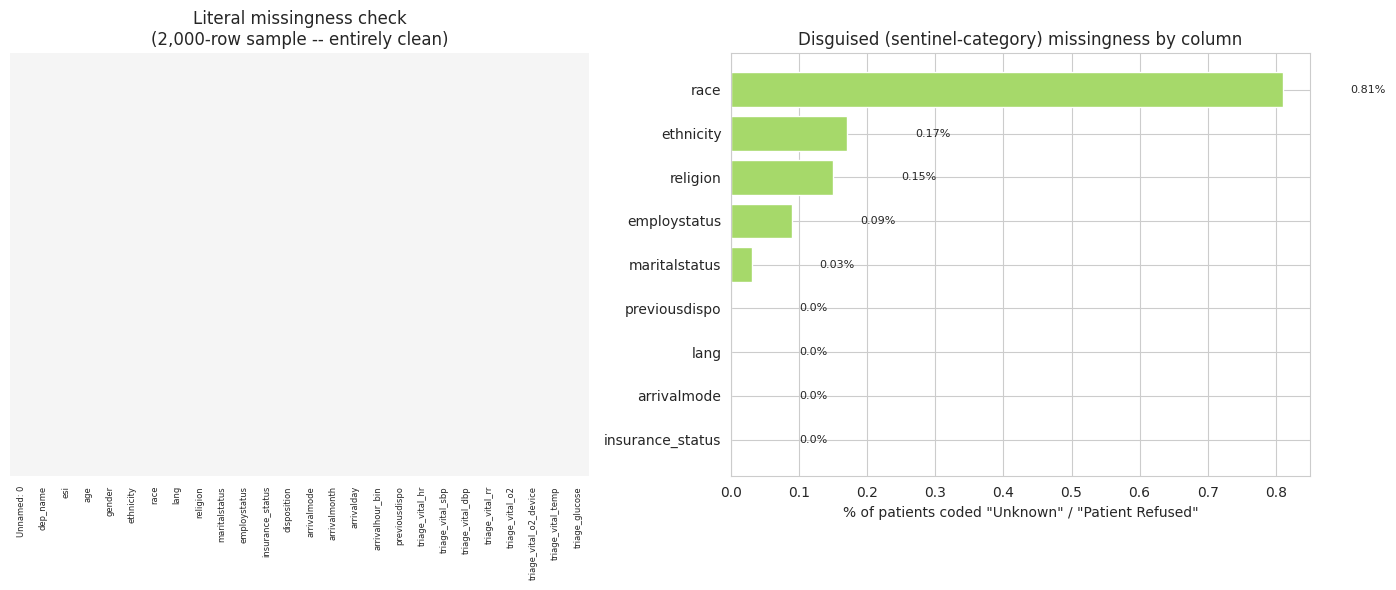

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
sample = df[non_cc_cols].isnull()
sns.heatmap(sample.sample(min(2000, len(sample)), random_state=42), cbar=False, cmap=['#f5f5f5'], ax=axes[0])
axes[0].set_title('Literal missingness check\n(2,000-row sample -- entirely clean)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=90, fontsize=6)
axes[0].set_yticks([])

plot_data = sentinel_table.sort_values('sentinel_pct', ascending=True)
# Using a brighter colormap for the bar chart
colors = ['#a6d96a' if p <= 1 else '#fdae61' if p <= 5 else '#d73027' for p in plot_data['sentinel_pct']] # Green, Orange, Red from RdYlGn_r
axes[1].barh(plot_data['column'], plot_data['sentinel_pct'], color=colors)
axes[1].set_xlabel('% of patients coded "Unknown" / "Patient Refused"')
axes[1].set_title('Disguised (sentinel-category) missingness by column')
for i, (col, pct) in enumerate(zip(plot_data['column'], plot_data['sentinel_pct'])):
    axes[1].text(pct + 0.1, i, f'{pct}%', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('dashboard_1_missingness.png', dpi=150, bbox_inches='tight')
plt.show()

**Clinical question answered:** is any field silently incomplete in a way that would bias a triage model? Answer: not through blank cells, but `race` shows the most disguised non-response of any field - worth a subgroup check before the Week 7 equity audit.

## 5. Outlier detection

Three complementary methods: IQR flags statistical spread, z-score flags distance from the mean, and clinical-plausibility thresholds flag values that would be dangerous or impossible regardless of the data's own distribution.

In [ ]:
iqr_rows = []
for c in vital_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = int(((df[c] < lo) | (df[c] > hi)).sum())
    iqr_rows.append({'feature': vital_labels[c], 'lower_bound': round(lo, 1), 'upper_bound': round(hi, 1),
                      'n_outliers': n_out, 'pct_outliers': round(n_out / len(df) * 100, 2)})
iqr_table = pd.DataFrame(iqr_rows).sort_values('pct_outliers', ascending=False)
iqr_table

,feature,lower_bound,upper_bound,n_outliers,pct_outliers
7,Glucose (mg/dL),31.5,195.5,5673,10.29
6,Temperature (°F),96.7,99.5,3554,6.45
4,Respiratory rate (breaths/min),13.0,21.0,2366,4.29
5,SpO2 (%),93.0,101.0,1505,2.73
2,Systolic BP (mmHg),74.5,190.5,1028,1.86
3,Diastolic BP (mmHg),41.5,117.5,726,1.32
1,Pulse (bpm),39.5,131.5,578,1.05
0,Age (years),-5.0,115.0,0,0.00


In [ ]:
z_rows = []
for c in vital_cols:
    z = np.abs(stats.zscore(df[c]))
    n_out = int((z > 3).sum())
    z_rows.append({'feature': vital_labels[c], 'n_outliers_z_gt3': n_out, 'pct_outliers': round(n_out / len(df) * 100, 2)})
z_table = pd.DataFrame(z_rows).sort_values('pct_outliers', ascending=False)
z_table

,feature,n_outliers_z_gt3,pct_outliers
7,Glucose (mg/dL),1363,2.47
6,Temperature (°F),858,1.56
5,SpO2 (%),706,1.28
4,Respiratory rate (breaths/min),514,0.93
2,Systolic BP (mmHg),434,0.79
1,Pulse (bpm),326,0.59
3,Diastolic BP (mmHg),325,0.59
0,Age (years),0,0.00


In [ ]:
clinical_bounds = {
    'triage_vital_hr': (30, 250, 'bpm'),
    'triage_vital_sbp': (40, 300, 'mmHg'),
    'triage_vital_dbp': (20, 200, 'mmHg'),
    'triage_vital_rr': (4, 60, 'breaths/min'),
    'triage_vital_o2': (50, 100, '%'),
    'triage_vital_temp': (90, 107, '°F'),
    'triage_glucose': (20, 1000, 'mg/dL'),
    'age': (0, 120, 'years')
}
plaus_rows = []
for c, (lo, hi, unit) in clinical_bounds.items():
    n_out = int(((df[c] < lo) | (df[c] > hi)).sum())
    plaus_rows.append({'feature': vital_labels[c], 'clinically_valid_range': f'{lo}-{hi} {unit}', 'n_implausible': n_out})
plaus_table = pd.DataFrame(plaus_rows)
plaus_table

,feature,clinically_valid_range,n_implausible
0,Pulse (bpm),30-250 bpm,0
1,Systolic BP (mmHg),40-300 mmHg,0
2,Diastolic BP (mmHg),20-200 mmHg,0
3,Respiratory rate (breaths/min),4-60 breaths/min,4
4,SpO2 (%),50-100 %,0
5,Temperature (°F),90-107 °F,0
6,Glucose (mg/dL),20-1000 mg/dL,8
7,Age (years),0-120 years,0


**Note:** IQR flags respiratory rate and glucose most (4.3% and 10.3% of patients respectively) simply because both are naturally skewed distributions, not because those values are wrong. Z-score agrees on direction but flags far fewer patients. The clinical-plausibility check matters most for data-quality sign-off: only 4 respiratory-rate readings and 8 glucose readings fall outside a range that would be dangerous or physiologically impossible - this dataset is not full of entry errors, it's full of genuinely sick patients with legitimately extreme vitals.

## 6. Dashboard - Plot 2: box plots of vitals (outlier view)

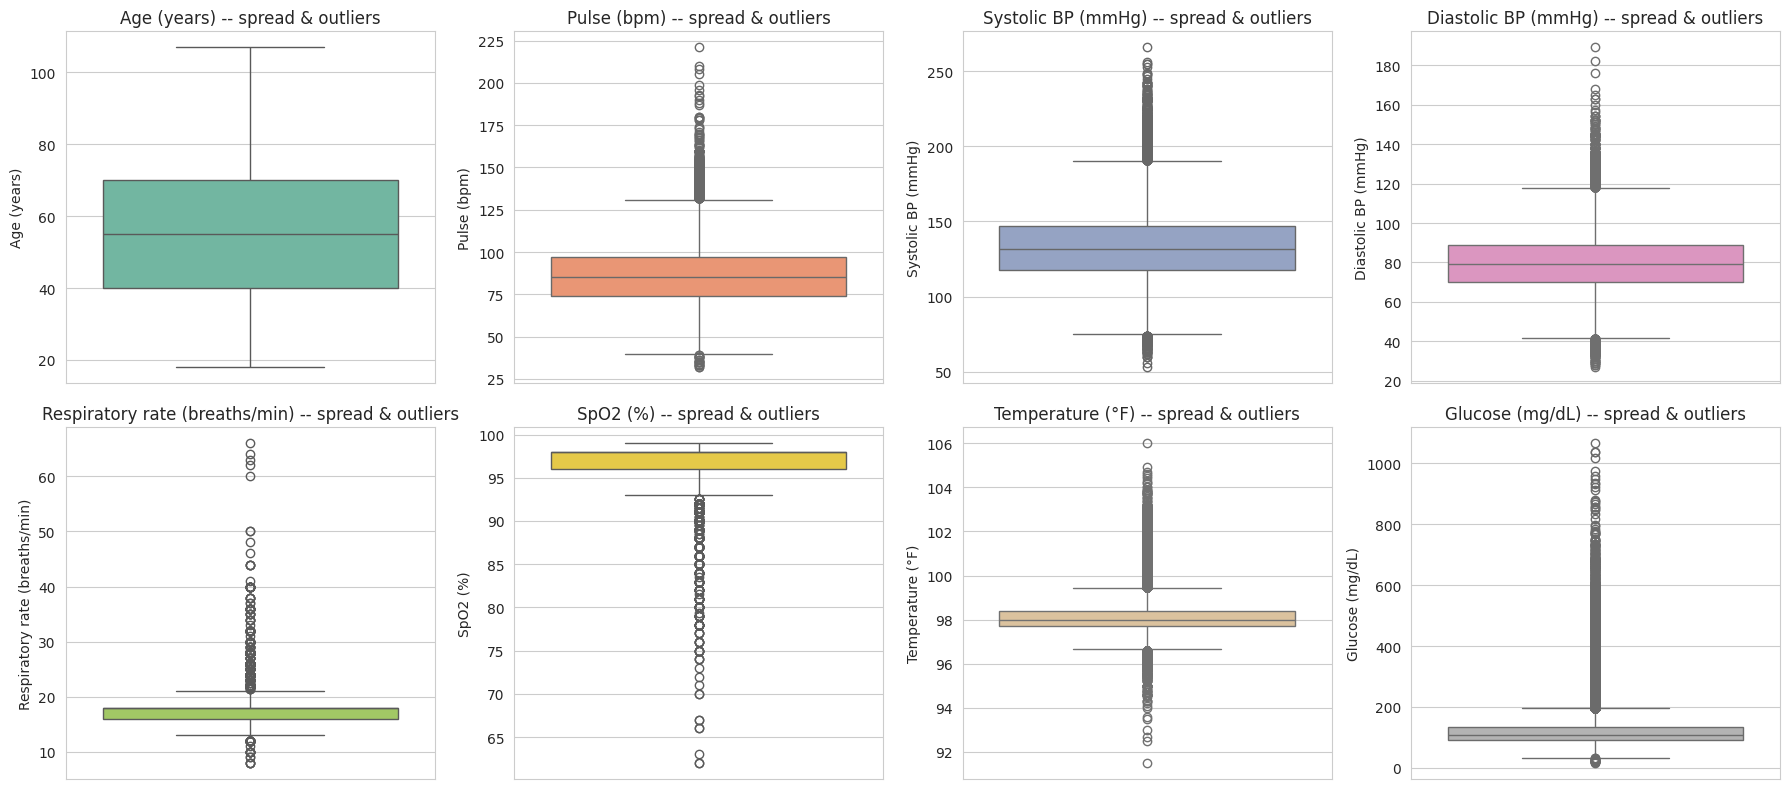

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
box_colors = sns.color_palette('Set2', len(vital_cols))
for ax, c, col in zip(axes.flat, vital_cols, box_colors):
    sns.boxplot(y=df[c], ax=ax, color=col)
    ax.set_ylabel(vital_labels[c])
    ax.set_title(f'{vital_labels[c]} -- spread & outliers')
plt.tight_layout()
plt.savefig('dashboard_2_vital_boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

**Clinical question answered:** which vitals have the widest genuine spread, and where do the statistical outliers sit relative to the bulk of patients? Glucose and respiratory rate show the longest tails, consistent with the outlier tables above.

## 7. Distribution analysis of key features

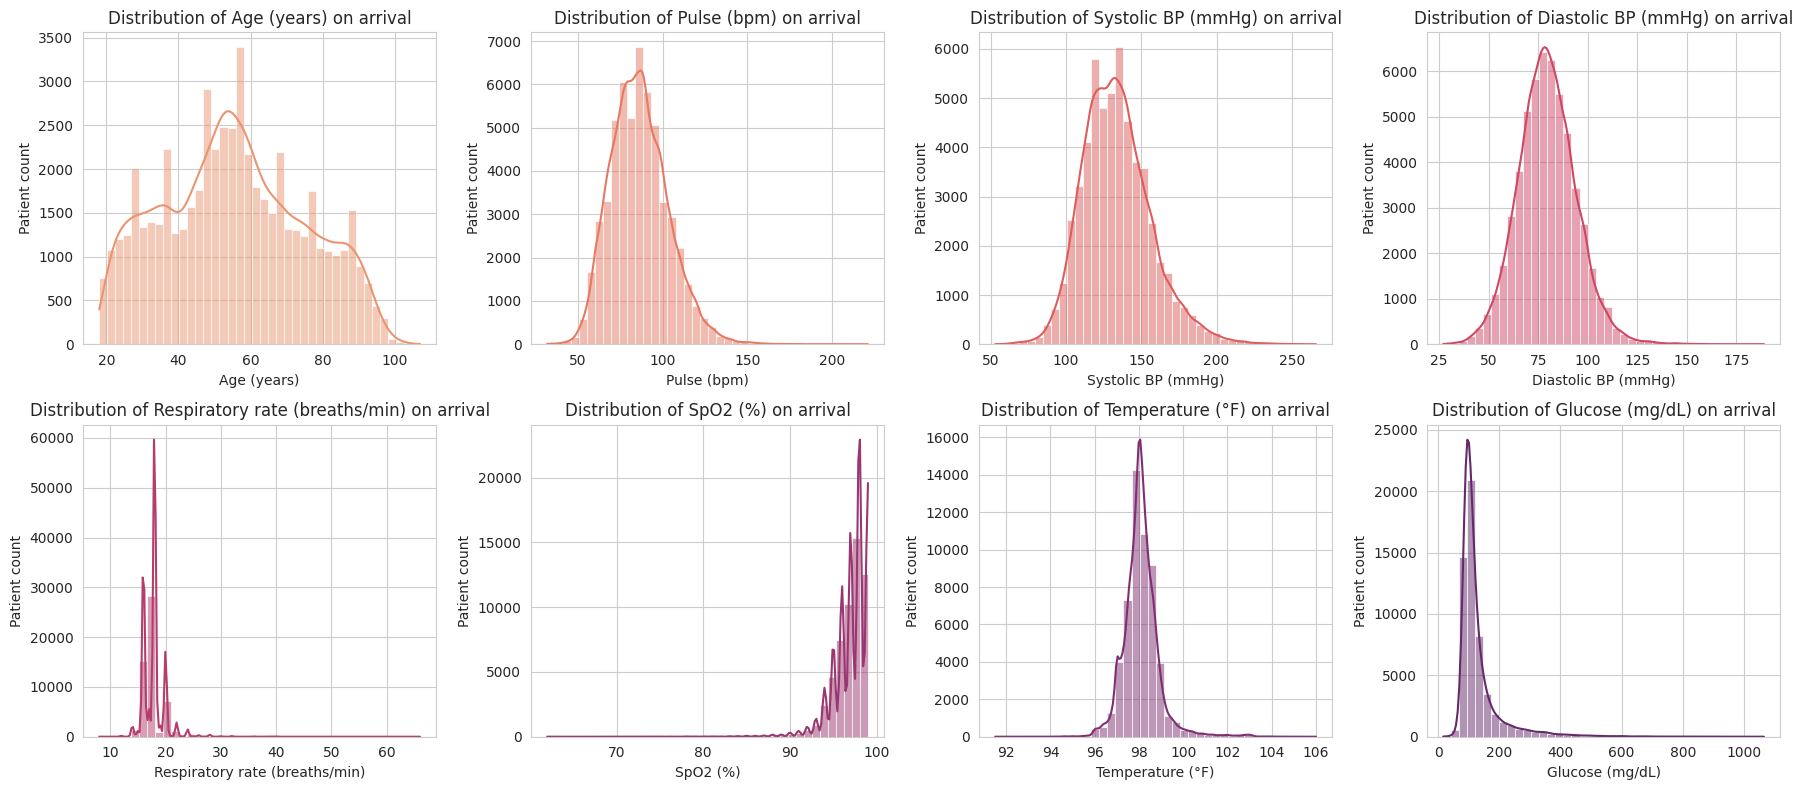

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
hist_colors = sns.color_palette('flare', len(vital_cols))
for ax, c, col in zip(axes.flat, vital_cols, hist_colors):
    sns.histplot(df[c], kde=True, ax=ax, color=col, bins=40)
    ax.set_xlabel(vital_labels[c])
    ax.set_ylabel('Patient count')
    ax.set_title(f'Distribution of {vital_labels[c]} on arrival')
plt.tight_layout()
plt.savefig('dashboard_3_vital_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

**Note:** heart rate, blood pressure, and temperature are approximately unimodal and roughly bell-shaped, consistent with a general adult ED population. Glucose is right-skewed (long tail toward high values) - clinically expected, since a subset of ED patients present with hyperglycaemic emergencies. SpO2 is left-skewed and ceiling-heavy at 98-99%, exactly what healthy oxygenation should look like.

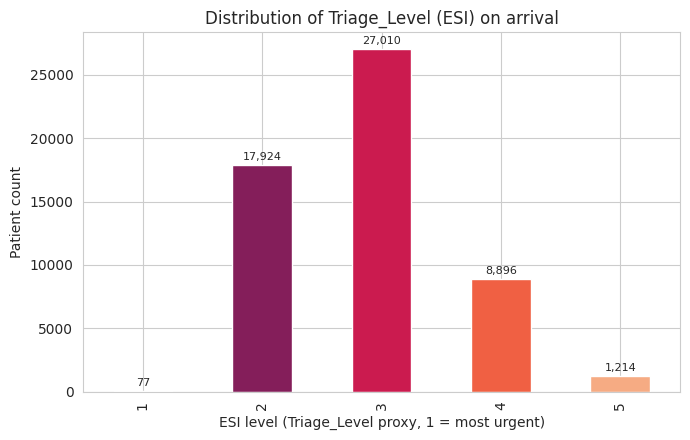

In [ ]:
fig, ax = plt.subplots(figsize=(7, 4.5))
esi_counts = df['esi'].value_counts().sort_index()
esi_colors = sns.color_palette('rocket', len(esi_counts))
esi_counts.plot(kind='bar', color=esi_colors, ax=ax)
ax.set_xlabel('ESI level (Triage_Level proxy, 1 = most urgent)')
ax.set_ylabel('Patient count')
ax.set_title('Distribution of Triage_Level (ESI) on arrival')
for i, v in enumerate(esi_counts):
    ax.text(i, v + 400, f'{v:,}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('dashboard_4_esi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Clinical question answered:** is the target variable balanced enough to model directly? No - ESI 1 (most urgent) is 0.14% of patients (77 of 55,121) vs. ~49% at ESI 3. This is clinically expected but the Week 6 model needs class weighting or a recall-focused metric for the rare, high-stakes classes.

## 8. Dashboard - Plot 3: vitals by Triage_Level (violin plots)

/tmp/ipykernel_1529/1905502744.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='esi', y=c, data=df, ax=ax, palette=PALETTE, inner='quartile')
/tmp/ipykernel_1529/1905502744.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='esi', y=c, data=df, ax=ax, palette=PALETTE, inner='quartile')
/tmp/ipykernel_1529/1905502744.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='esi', y=c, data=df, ax=ax, palette=PALETTE, inner='quartile')
/tmp/ipykernel_1529/1905502744.py:4: FutureWarning: 

Passing `palette` without assigning `hue

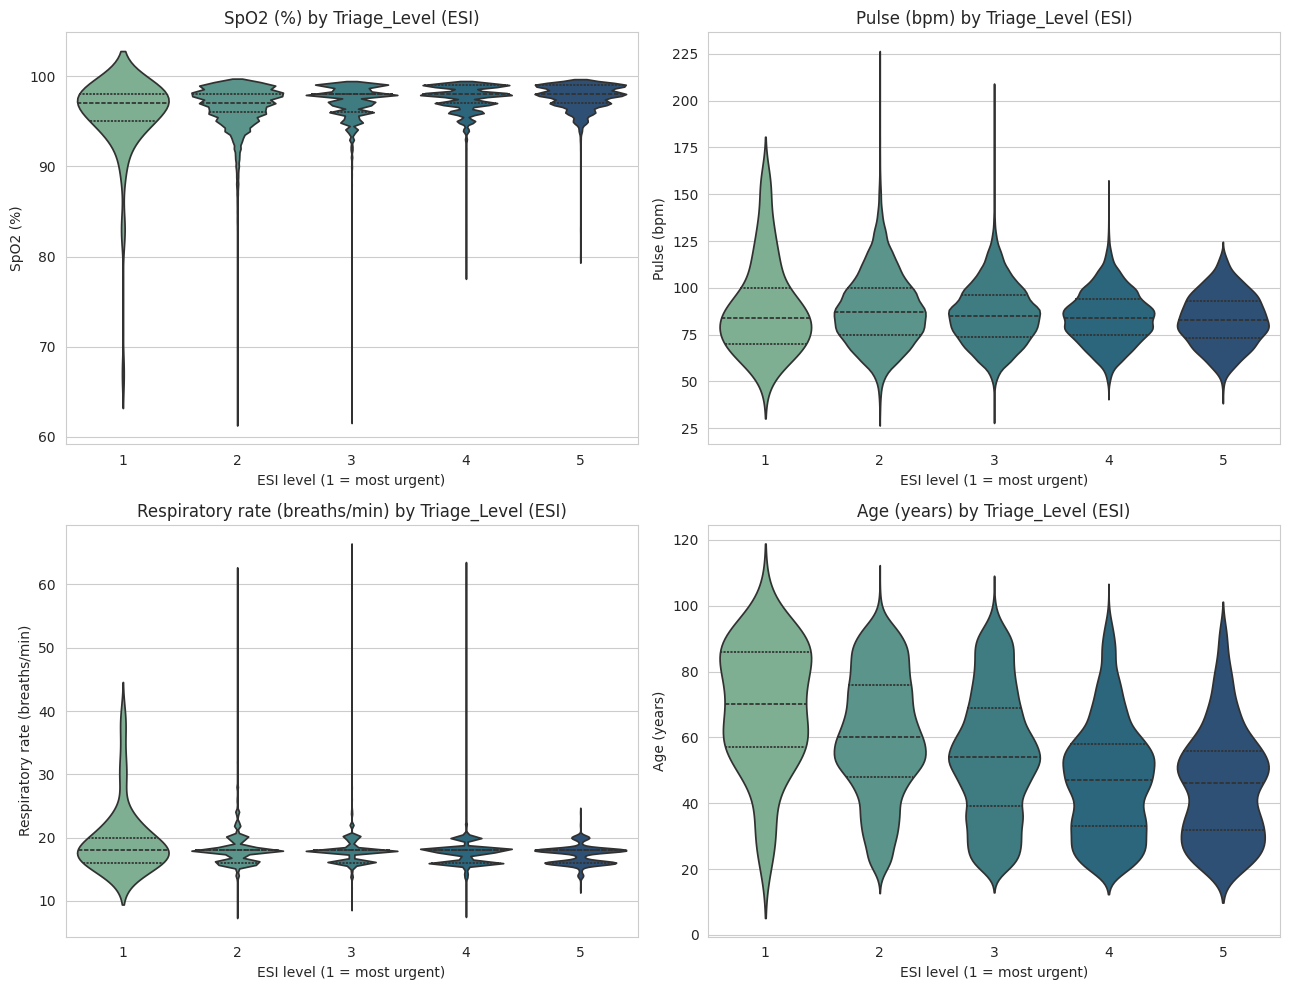

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
plot_vitals = ['triage_vital_o2', 'triage_vital_hr', 'triage_vital_rr', 'age']
for ax, c in zip(axes.flat, plot_vitals):
    sns.violinplot(x='esi', y=c, data=df, ax=ax, palette=PALETTE, inner='quartile')
    ax.set_xlabel('ESI level (1 = most urgent)')
    ax.set_ylabel(vital_labels[c])
    ax.set_title(f'{vital_labels[c]} by Triage_Level (ESI)')
plt.tight_layout()
plt.savefig('dashboard_5_vitals_by_esi_violin.png', dpi=150, bbox_inches='tight')
plt.show()

**Clinical question answered:** do vitals actually move with acuity the way clinical theory predicts? Yes: SpO2 is visibly lower and pulse/respiratory rate visibly higher at ESI 1 than ESI 5, and age skews older at ESI 1 - one of the strongest feasibility signals in the whole notebook.

## 9. Correlation analysis with the target variable

Spearman correlation is used throughout since `esi` is ordinal, not a true numeric scale.

In [ ]:
esi_numeric = df['esi'].astype(int)
target_corr = df[vital_cols].corrwith(esi_numeric, method='spearman').sort_values()
target_corr_display = target_corr.rename(index=vital_labels)
target_corr_display.to_frame('spearman_corr_with_esi')

,spearman_corr_with_esi
Age (years),-0.238160
Glucose (mg/dL),-0.110876
Pulse (bpm),-0.073215
Respiratory rate (breaths/min),-0.056469
Temperature (°F),0.010129
Systolic BP (mmHg),0.019689
Diastolic BP (mmHg),0.060635
SpO2 (%),0.158817


## 10. Dashboard - Plot 4: correlation heatmap

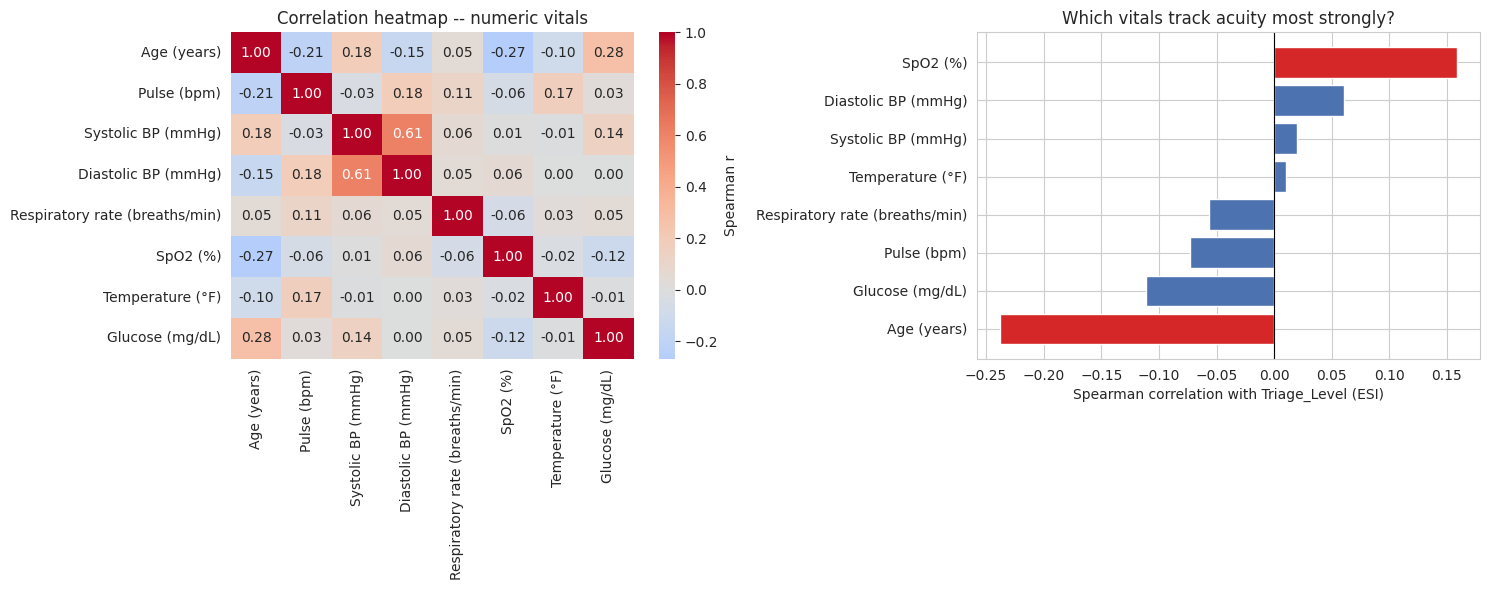

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

corr_matrix = df[vital_cols].corr(method='spearman').rename(index=vital_labels, columns=vital_labels)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=axes[0], cbar_kws={'label': 'Spearman r'})
axes[0].set_title('Correlation heatmap -- numeric vitals')

colors = ['#d62728' if abs(v) > 0.15 else '#4c72b0' for v in target_corr_display.values]
axes[1].barh(target_corr_display.index, target_corr_display.values, color=colors)
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_xlabel('Spearman correlation with Triage_Level (ESI)')
axes[1].set_title('Which vitals track acuity most strongly?')
plt.tight_layout()
plt.savefig('dashboard_6_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

**Clinical question answered:** which vitals are most predictive of triage level, and are any redundant with each other? Age (r≈-0.24) and SpO2 (r≈+0.16) show the strongest single-vital association with ESI. Systolic/diastolic BP correlate moderately with each other but only weakly with ESI alone, meaning blood pressure alone is a poor triage predictor in this dataset.

## 11. Chief complaints vs. Triage_Level

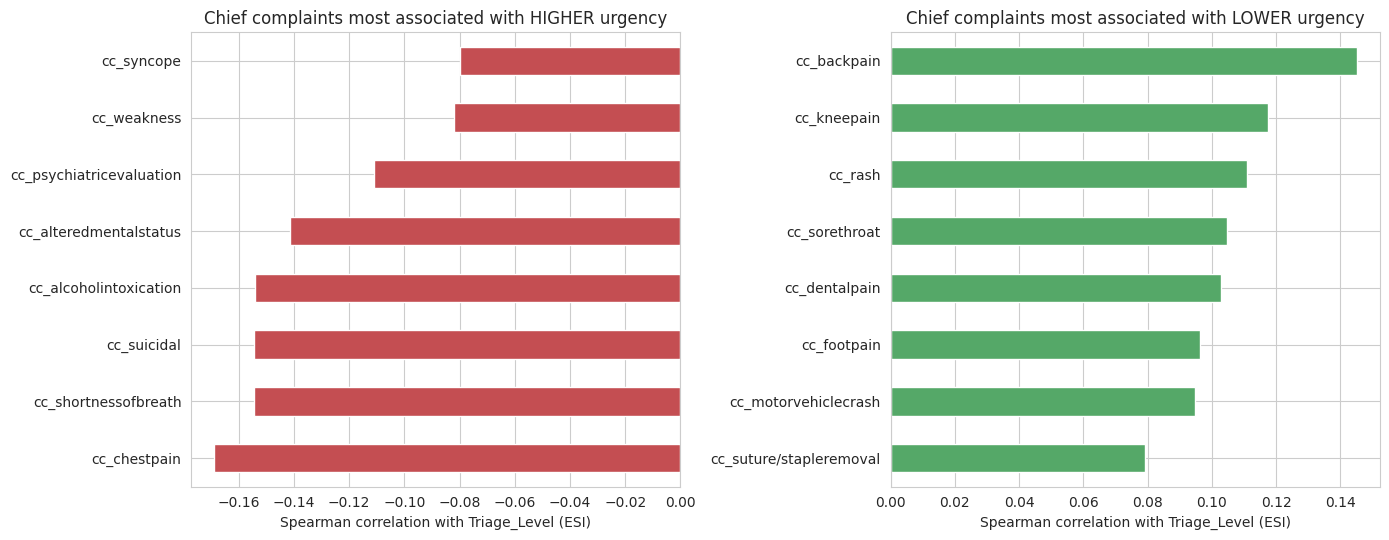

In [ ]:
cc_cols = [c for c in df.columns if c.startswith('cc_')]
cc_variance = df[cc_cols].var()
cc_cols_nonconstant = cc_variance[cc_variance > 0].index.tolist()
cc_corr = df[cc_cols_nonconstant].corrwith(esi_numeric, method='spearman').dropna().sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
cc_corr.head(8).sort_values(ascending=True).plot(kind='barh', ax=axes[0], color='#c44e52')
axes[0].set_xlabel('Spearman correlation with Triage_Level (ESI)')
axes[0].set_title('Chief complaints most associated with HIGHER urgency')

cc_corr.tail(8).sort_values(ascending=True).plot(kind='barh', ax=axes[1], color='#55a868')
axes[1].set_xlabel('Spearman correlation with Triage_Level (ESI)')
axes[1].set_title('Chief complaints most associated with LOWER urgency')
plt.tight_layout()
plt.savefig('dashboard_7_complaints_vs_esi.png', dpi=150, bbox_inches='tight')
plt.show()

**Note:** chest pain, shortness of breath, suicidal ideation, alcohol intoxication, and altered mental status are the complaints most associated with higher urgency - all clinically sensible high-acuity presentations. Ear pain, dental pain, and suture/staple removal sit at the low-urgency end, exactly as a clinician would expect.

## 12. Additional dashboard views - demographics, joint relationships, grouped acuity

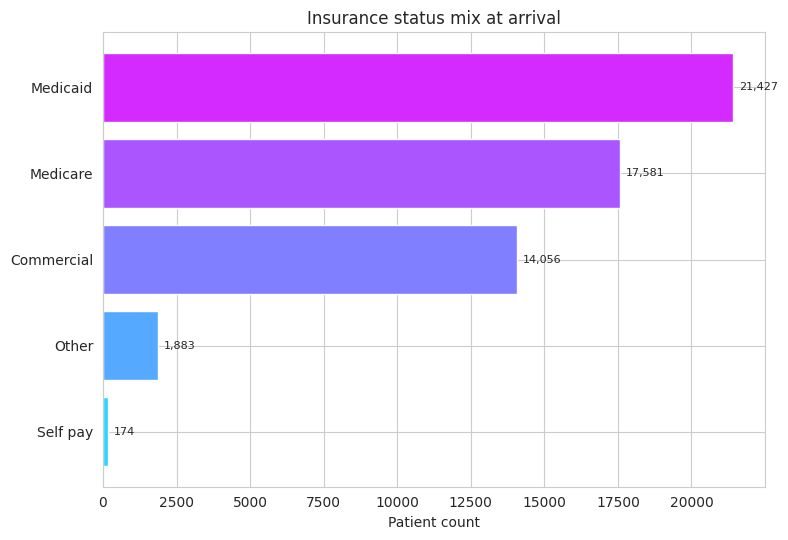

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5.5))
insurance_counts = df['insurance_status'].value_counts().sort_values()
bar_colors = sns.color_palette('cool', len(insurance_counts))
ax.barh(insurance_counts.index, insurance_counts.values, color=bar_colors)
ax.set_xlabel('Patient count')
ax.set_title('Insurance status mix at arrival')
for i, v in enumerate(insurance_counts.values):
    ax.text(v + 200, i, f'{v:,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('dashboard_8_insurance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

**Clinical question answered:** how does the payer mix compare across sources of coverage? The distribution looks like a plausible general-ED payer mix rather than a single-payer artefact - worth carrying into the equity audit alongside the demographic missingness check in Section 3.

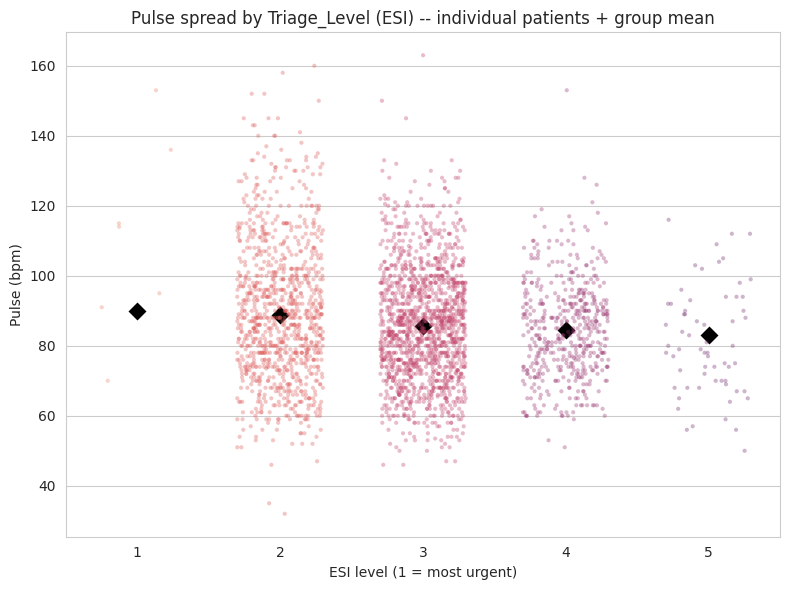

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
sample_df = df.sample(min(3000, len(df)), random_state=7)
sns.stripplot(x='esi', y='triage_vital_hr', data=sample_df, hue='esi', palette='flare',
              alpha=0.35, size=3, jitter=0.3, ax=ax, legend=False)
sns.pointplot(x='esi', y='triage_vital_hr', data=df, color='black', markers='D',
              linestyle='none', errorbar=None, ax=ax)
ax.set_xlabel('ESI level (1 = most urgent)')
ax.set_ylabel(vital_labels['triage_vital_hr'])
ax.set_title('Pulse spread by Triage_Level (ESI) -- individual patients + group mean')
plt.tight_layout()
plt.savefig('dashboard_12_pulse_strip.png', dpi=150, bbox_inches='tight')
plt.show()

**Clinical question answered:** is the pulse-vs-acuity relationship driven by a few outliers or does it hold across the whole patient spread? The black diamonds (group means) step downward from ESI 1 to ESI 5 while the full patient cloud confirms it's a genuine population-level signal, not a handful of extreme cases.

/tmp/ipykernel_1529/2486815272.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('esi')[top10_complaints].mean().T * 100


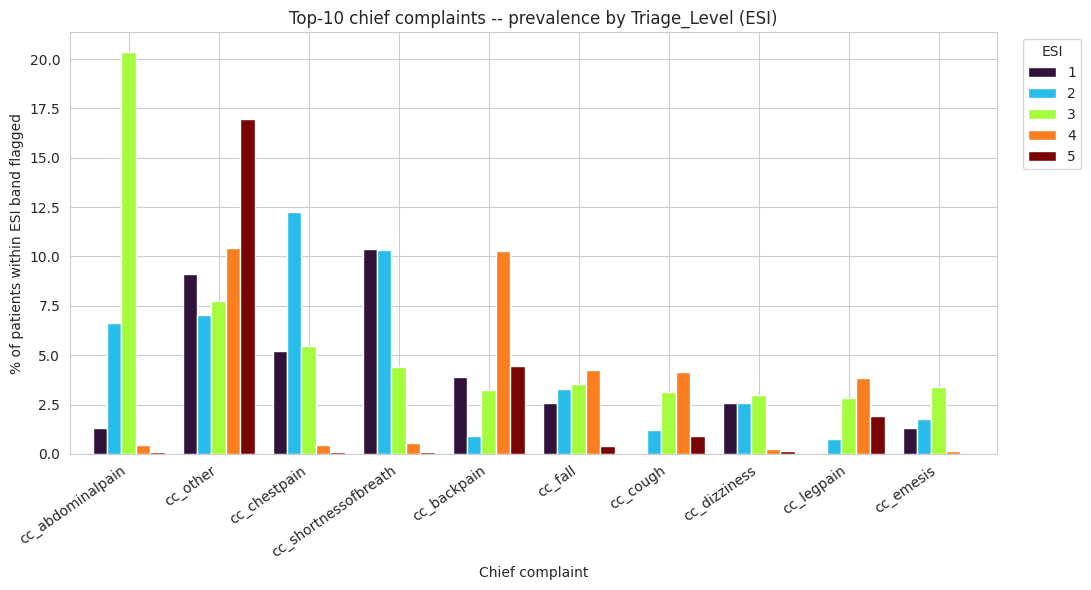

In [ ]:
top10_complaints = df[cc_cols_nonconstant].sum().sort_values(ascending=False).head(10).index.tolist()
grouped = df.groupby('esi')[top10_complaints].mean().T * 100

fig, ax = plt.subplots(figsize=(11, 6))
grouped.plot(kind='bar', ax=ax, colormap='turbo', width=0.8)
ax.set_xlabel('Chief complaint')
ax.set_ylabel('% of patients within ESI band flagged')
ax.set_title('Top-10 chief complaints -- prevalence by Triage_Level (ESI)')
ax.legend(title='ESI', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.savefig('dashboard_13_complaints_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()

**Clinical question answered:** do the highest-volume complaints skew toward any particular acuity band? Chest pain and shortness of breath both show a visibly higher share of ESI 2 flagging than lower-acuity complaints like dental pain - reinforcing the Section 11 correlation findings with a complaint-by-complaint view.

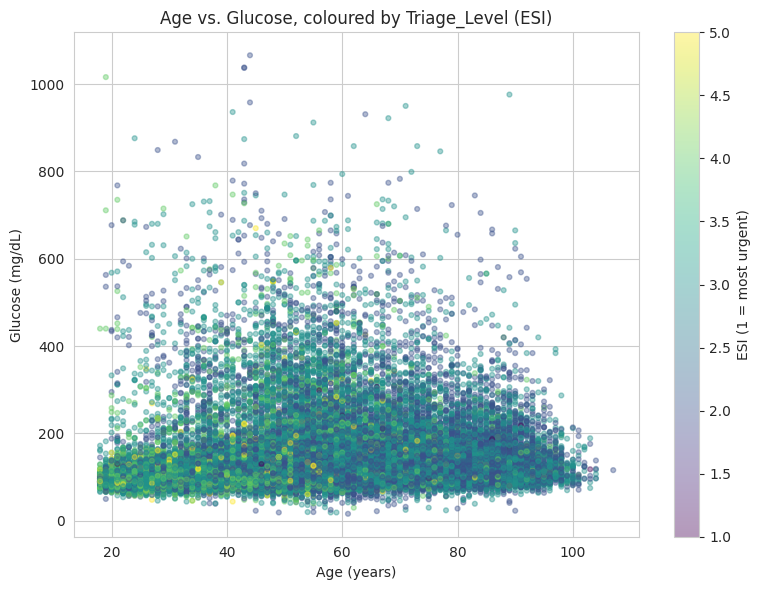

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
esi_int = df['esi'].astype(int)
scatter = ax.scatter(df['age'], df['triage_glucose'], c=esi_int, cmap='viridis', alpha=0.4, s=12)
ax.set_xlabel(vital_labels['age'])
ax.set_ylabel(vital_labels['triage_glucose'])
ax.set_title('Age vs. Glucose, coloured by Triage_Level (ESI)')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('ESI (1 = most urgent)')
plt.tight_layout()
plt.savefig('dashboard_9_age_glucose_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

**Clinical question answered:** do age and glucose jointly separate acuity better than either does alone? The darkest (most urgent, ESI 1) points skew toward the upper age range, but glucose extremes appear across all ages - confirming both carry partly independent signal for Week 6.

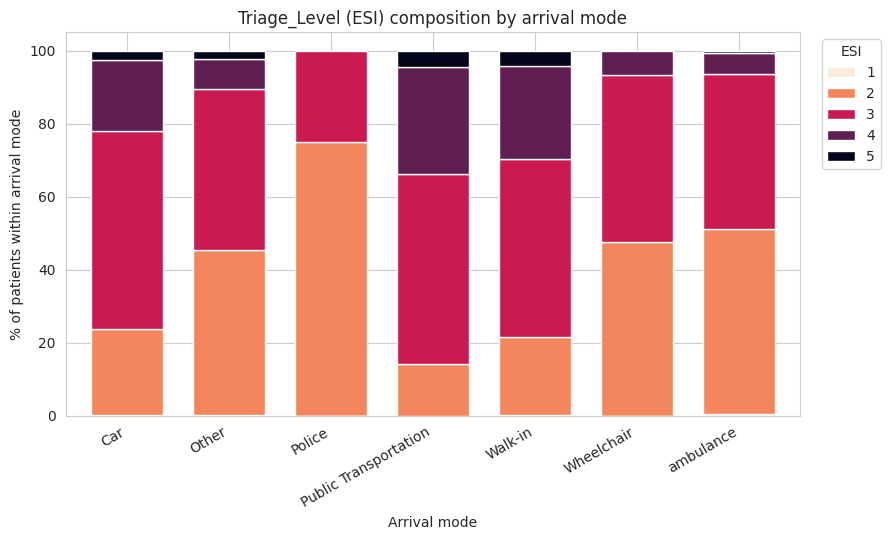

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5.5))
mode_esi = pd.crosstab(df['arrivalmode'], df['esi'], normalize='index') * 100
mode_esi = mode_esi.loc[mode_esi.sum(axis=1).sort_values(ascending=False).index]
mode_esi.plot(kind='bar', stacked=True, ax=ax, colormap='rocket_r', width=0.7)
ax.set_xlabel('Arrival mode')
ax.set_ylabel('% of patients within arrival mode')
ax.set_title('Triage_Level (ESI) composition by arrival mode')
ax.legend(title='ESI', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('dashboard_10_arrivalmode_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

**Clinical question answered:** does how a patient arrives predict how urgent they are? Arrival modes associated with pre-hospital clinical assessment (e.g. ambulance) show a visibly higher share of low-ESI (urgent) patients than walk-in, suggesting `arrivalmode` is worth testing as a Week 6 feature.

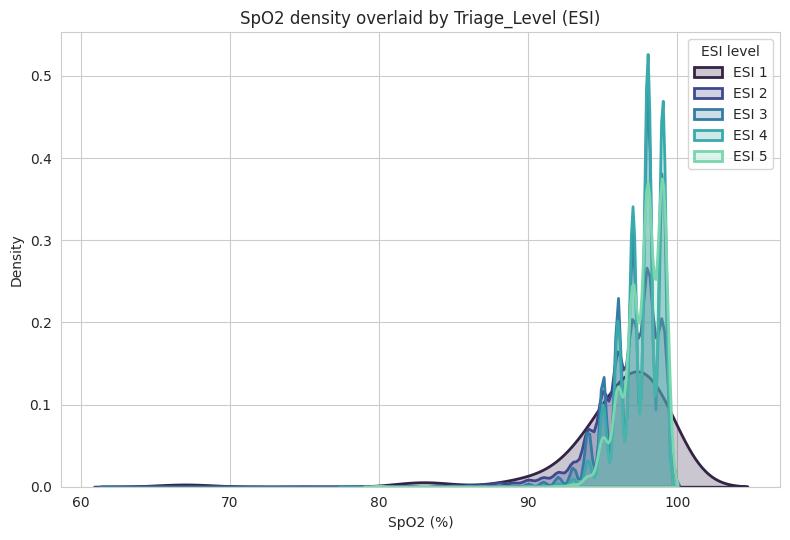

In [ ]:
fig, ax = plt.subplots(figsize=(8, 5.5))
ridge_colors = sns.color_palette('mako', 5)
for level, color in zip([1, 2, 3, 4, 5], ridge_colors):
    subset = df.loc[df['esi'] == level, 'triage_vital_o2']
    sns.kdeplot(subset, ax=ax, color=color, fill=True, alpha=0.25, linewidth=2, label=f'ESI {level}')
ax.set_xlabel(vital_labels['triage_vital_o2'])
ax.set_ylabel('Density')
ax.set_title('SpO2 density overlaid by Triage_Level (ESI)')
ax.legend(title='ESI level')
plt.tight_layout()
plt.savefig('dashboard_11_spo2_kde_overlay.png', dpi=150, bbox_inches='tight')
plt.show()

**Clinical question answered:** how much do SpO2 distributions actually shift between acuity levels, once you look past the summary means? ESI 1's density visibly shifts left (lower SpO2) and widens compared to ESI 5, confirming the Section 8 violin-plot finding with a complementary view.

## 13. Summary of findings

In [ ]:
summary = pd.DataFrame({
    'Area': ['Literal missingness', 'Disguised missingness', 'Dtype issues', 'Outliers (clinical-plausibility)',
             'Target variable', 'Vitals distribution', 'Vitals vs. acuity', 'Chief complaints vs. acuity'],
    'Finding': [
        '0% across all 226 columns',
        'Under 1% per field; concentrated in race, then ethnicity/religion',
        'esi and triage_vital_o2_device were float64, now corrected to ordered category / category',
        'Only 4 respiratory-rate and 8 glucose readings fall outside clinically valid ranges',
        'esi severely imbalanced -- ESI 1 = 0.14% of patients',
        'Approximately normal for HR/BP/temp; right-skewed glucose; left-skewed, ceiling-heavy SpO2',
        'SpO2, pulse, respiratory rate, and age all move with acuity in the clinically expected direction',
        'Chest pain, SOB, suicidal ideation, intoxication, altered mental status most associated with higher urgency'
    ]
})
summary

,Area,Finding
0,Literal missingness,0% across all 226 columns
1,Disguised missingness,"Under 1% per field; concentrated in race, then..."
2,Dtype issues,"esi and triage_vital_o2_device were float64, n..."
3,Outliers (clinical-plausibility),Only 4 respiratory-rate and 8 glucose readings...
4,Target variable,esi severely imbalanced -- ESI 1 = 0.14% of pa...
5,Vitals distribution,Approximately normal for HR/BP/temp; right-ske...
6,Vitals vs. acuity,"SpO2, pulse, respiratory rate, and age all mov..."
7,Chief complaints vs. acuity,"Chest pain, SOB, suicidal ideation, intoxicati..."


## Week 6: Baseline Machine Learning Models

This notebook continues from the exploratory data analysis completed in Week 5.

The aim of Week 6 is to develop and evaluate baseline machine learning models for predicting emergency department triage levels.

Three approaches are compared:

1. Logistic Regression classifier
2. Decision Tree classifier
3. Stratified random baseline using DummyClassifier

The models are evaluated using clinically relevant classification metrics and confusion matrices.

In [26]:
import pandas as pd
import numpy as np

df = pd.read_csv(
    DATA_PATH
)

df.head()

,Unnamed: 0,dep_name,esi,age,gender,ethnicity,race,lang,religion,maritalstatus,...,cc_vaginaldischarge,cc_vaginalpain,cc_weakness,cc_wheezing,cc_withdrawal-alcohol,cc_woundcheck,cc_woundinfection,cc_woundre-evaluation,cc_wristinjury,cc_wristpain
0,7,A,4.0,87.0,Female,Hispanic or Latino,Other,Other,Pentecostal,Widowed,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,17,B,2.0,53.0,Male,Hispanic or Latino,Other,English,Catholic,Significant Other,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,40,A,2.0,49.0,Female,Non-Hispanic,White or Caucasian,English,Catholic,Married,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,47,A,3.0,22.0,Female,Hispanic or Latino,White or Caucasian,English,Catholic,Single,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,60,A,2.0,62.0,Male,Non-Hispanic,White or Caucasian,English,Protestant,Divorced,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55121 entries, 0 to 55120
Columns: 226 entries, Unnamed: 0 to cc_wristpain
dtypes: float64(210), int64(1), object(15)
memory usage: 95.0+ MB


In [28]:
df.columns

Index(['Unnamed: 0', 'dep_name', 'esi', 'age', 'gender', 'ethnicity', 'race',
       'lang', 'religion', 'maritalstatus',
       ...
       'cc_vaginaldischarge', 'cc_vaginalpain', 'cc_weakness', 'cc_wheezing',
       'cc_withdrawal-alcohol', 'cc_woundcheck', 'cc_woundinfection',
       'cc_woundre-evaluation', 'cc_wristinjury', 'cc_wristpain'],
      dtype='object', length=226)

In [29]:
df.isnull().sum()

,0
Unnamed: 0,0
dep_name,0
esi,0
age,0
gender,0
...,...
cc_woundcheck,0
cc_woundinfection,0
cc_woundre-evaluation,0
cc_wristinjury,0


In [4]:
# Build the target, then strip out anything that leaks the answer
import pandas as pd

# Define DATA_PATH to ensure it's available
DATA_PATH = '/content/drive/MyDrive/yaleemmlc_admissionprediction_triage.csv'

# Ensure df is loaded and esi is correctly typed before proceeding
df = pd.read_csv(DATA_PATH, low_memory=False)
df['esi'] = pd.Categorical(df['esi'].astype(int), categories=[1, 2, 3, 4, 5], ordered=True)
df['Triage_Level'] = df['esi'].astype(int)

# esi IS the target (identical to Triage_Level); disposition & previousdispo
# are known only AFTER triage; Unnamed: 0 is just a row index.
leakage_cols = ['esi', 'disposition', 'previousdispo', 'Unnamed: 0']

df["Triage_Level"].value_counts()

,count
Triage_Level,
3,27010
2,17924
4,8896
5,1214
1,77


In [6]:
X = df.drop(columns=['Triage_Level'] + leakage_cols)
y = df["Triage_Level"]

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_columns = X.select_dtypes(
    include="object"
).columns

numeric_columns = X.select_dtypes(
    exclude="object"
).columns

preprocessor = ColumnTransformer(

    transformers=[

        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_columns
        ),
        (
            "numerical",
            StandardScaler(),
            numeric_columns
        )

    ]

)

In [8]:
from sklearn.model_selection import train_test_split


X_train, X_test, y_train, y_test = train_test_split(

    X,
    y,

    test_size=0.2,

    stratify=y,

    random_state=42
)

The dataset was split using an 80/20 stratified train-test split. Stratification was used to maintain the distribution of triage categories between training and testing datasets. A random seed of 42 was selected to ensure reproducibility.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression


logistic_model = Pipeline(

    steps=[

        (
            "preprocessing",
            preprocessor
        ),

        (
            "model",
            LogisticRegression(
                max_iter=1000,
                random_state=42
            )
        )

    ]

)


logistic_model.fit(
    X_train,
    y_train
)


logistic_predictions = logistic_model.predict(
    X_test
)

In [10]:
from sklearn.tree import DecisionTreeClassifier


tree_model = Pipeline(

    steps=[

        (
            "preprocessing",
            preprocessor
        ),

        (
            "model",
            DecisionTreeClassifier(

                max_depth=5,

                random_state=42

            )
        )

    ]

)


tree_model.fit(
    X_train,
    y_train
)


tree_predictions = tree_model.predict(
    X_test
)

The Decision Tree maximum depth was limited to five levels to reduce overfitting and maintain interpretability. This is important for clinical decision-support systems where understanding model behaviour is valuable.

In [11]:
from sklearn.dummy import DummyClassifier


dummy_model = Pipeline(

    steps=[

        (
            "preprocessing",
            preprocessor
        ),

        (
            "model",
            DummyClassifier(

                strategy="stratified",

                random_state=42

            )
        )

    ]

)


dummy_model.fit(
    X_train,
    y_train
)


dummy_predictions = dummy_model.predict(
    X_test
)

In [12]:
from sklearn.metrics import classification_report


print("LOGISTIC REGRESSION")

print(
    classification_report(
        y_test,
        logistic_predictions
    )
)


print("DECISION TREE")

print(
    classification_report(
        y_test,
        tree_predictions
    )
)


print("DUMMY BASELINE")

print(
    classification_report(
        y_test,
        dummy_predictions
    )
)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

           1       0.40      0.25      0.31        16
           2       0.74      0.68      0.71      3585
           3       0.71      0.77      0.74      5402
           4       0.65      0.66      0.65      1779
           5       0.44      0.15      0.23       243

    accuracy                           0.71     11025
   macro avg       0.59      0.50      0.53     11025
weighted avg       0.70      0.71      0.70     11025

DECISION TREE
              precision    recall  f1-score   support

           1       0.00      0.00      0.00        16
           2       0.77      0.25      0.38      3585
           3       0.54      0.86      0.67      5402
           4       0.45      0.33      0.38      1779
           5       0.00      0.00      0.00       243

    accuracy                           0.56     11025
   macro avg       0.35      0.29      0.29     11025
weighted avg       0.59      0.56      0.51

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


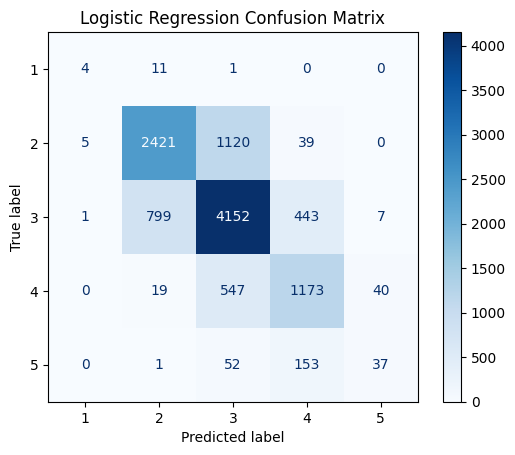

In [14]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay


ConfusionMatrixDisplay.from_predictions(

    y_test,

    logistic_predictions,

    cmap='Blues' # Changed colormap to 'Blues' for lighter colors

)

plt.title(
    "Logistic Regression Confusion Matrix"
)

plt.show()

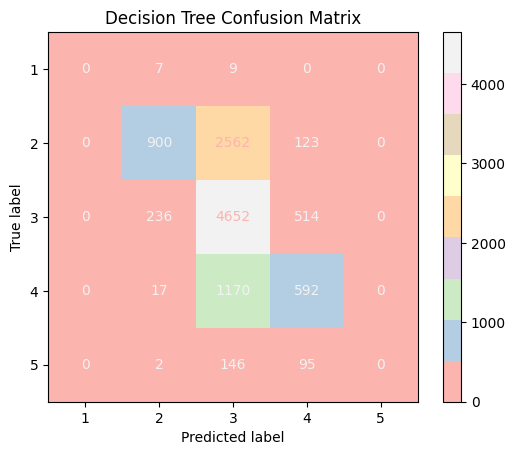

In [15]:
ConfusionMatrixDisplay.from_predictions(

    y_test,

    tree_predictions,

    cmap='Pastel1'

)

plt.title(
    "Decision Tree Confusion Matrix"
)

plt.show()

In [16]:
from sklearn.metrics import f1_score


macro_f1 = f1_score(

    y_test,

    logistic_predictions,

    average="macro"

)


weighted_f1 = f1_score(

    y_test,

    logistic_predictions,

    average="weighted"

)


print(
    "Macro F1:",
    macro_f1
)


print(
    "Weighted F1:",
    weighted_f1
)

Macro F1: 0.526578278313825
Weighted F1: 0.7021883006914819


## Macro F1 and Weighted F1 Interpretation

Macro F1 calculates performance by giving equal importance to each triage category. This is useful because emergency department datasets are often imbalanced, meaning some urgent categories have fewer examples than lower urgency categories.

Weighted F1 considers the number of patients in each category. This means common triage levels contribute more strongly to the final score.

The difference between these metrics highlights that strong performance on common classes does not always represent equally strong performance across all urgency levels. In clinical applications, rare but high-risk patients remain important because incorrect classification may delay treatment.

In [19]:
from sklearn.metrics import accuracy_score

results = pd.DataFrame({

"Model":[

"Dummy Classifier",

"Logistic Regression",

"Decision Tree"

],

"Accuracy":[

accuracy_score(y_test,dummy_predictions),

accuracy_score(y_test,logistic_predictions),

accuracy_score(y_test,tree_predictions)

],

"Macro F1":[

f1_score(y_test,dummy_predictions,average="macro"),

f1_score(y_test,logistic_predictions,average="macro"),

f1_score(y_test,tree_predictions,average="macro")

],

"Weighted F1":[

f1_score(y_test,dummy_predictions,average="weighted"),

f1_score(y_test,logistic_predictions,average="weighted"),

f1_score(y_test,tree_predictions,average="weighted")

]

})


results

,Model,Accuracy,Macro F1,Weighted F1
0,Dummy Classifier,0.375420,0.203876,0.374584
1,Logistic Regression,0.706304,0.526578,0.702188
2,Decision Tree,0.557279,0.285627,0.511873


## Reproducibility

Machine learning models were developed using:

- Dataset: yaleemmlc_admissionprediction_triage.csv
- Train/test split: 80/20
- Stratification: Triage_Level
- Random seed: 42
- Decision Tree maximum depth: 5

The fixed random seed ensures that results can be reproduced.